<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import anndata as ad
import scanpy as sc
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))

# Intro

We'll walk through how to run CellSweep on a scRNA-seq dataset. For this example, we'll be using the following dataset:

PBMC 1K from healthy donor (10x Genomics): https://www.10xgenomics.com/datasets/human-pbmc-from-a-healthy-donor-1-k-cells-v-2-2-standard-4-0-0

## Set up paths and parameters

In [3]:
expected_cells = 1000

data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "pbmc1k")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "pbmc1k")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

## Download data

In [4]:
adata_raw_path = os.path.join(data_dir, "sc5p_v2_hs_PBMC_1k_raw_feature_bc_matrix.h5")
if not os.path.exists(adata_raw_path):
    !curl -L -o "{adata_raw_path}" "https://cf.10xgenomics.com/samples/cell-vdj/4.0.0/sc5p_v2_hs_PBMC_1k/sc5p_v2_hs_PBMC_1k_raw_feature_bc_matrix.h5"

## Load in data

In [5]:
adata_raw = sc.read_10x_h5(adata_raw_path)
adata_raw.var_names_make_unique()

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Knee plot - use this output to estimate umi_cutoff
This adds in adata.obs["is_empty"] (boolean). Choice of empty droplet detection method does not substantially change results, although we recommend being erring on the side of including more cells rather than fewer.

UMI cutoff for expected cells (1000): 257.00


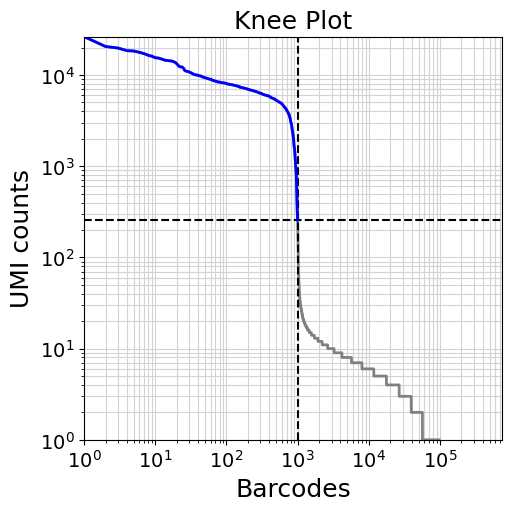

In [6]:
umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))
adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff)

## Determine cell types - here, we use Leiden clusters, but you can use any method you like
This adds in adata.obs["celltype"] (categorical). Choice of cell type assignment method method does not substantially change results.

In [7]:
# model_pkl = "Immune_All_High.pkl"  # for cell type assignment with celltypist
# adata_celltype = cs_utils.determine_cell_types(adata_raw, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=2)

adata_celltype = adata_raw[~adata_raw.obs["is_empty"]].copy()
sc.pp.filter_cells(adata_celltype, min_genes=10)
sc.pp.filter_genes(adata_celltype, min_cells=1)

adata_celltype.var["mt"] = adata_celltype.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata_celltype, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
adata_celltype = adata_celltype[adata_celltype.obs.pct_counts_mt < 25, :]

adata_celltype.layers["counts"] = adata_celltype.X.copy()
sc.pp.normalize_total(adata_celltype, target_sum=1e4)
sc.pp.log1p(adata_celltype)
sc.pp.highly_variable_genes(adata_celltype, n_top_genes=2000)
sc.tl.pca(adata_celltype, svd_solver="arpack", random_state=42)
sc.pp.neighbors(adata_celltype, n_neighbors=15, n_pcs=50)
sc.tl.leiden(adata_celltype, flavor="igraph", n_iterations=2, resolution=1.0, random_state=42)

adata_raw.obs["celltype"] = adata_celltype.obs["leiden"].cat.add_categories(["empty"]).reindex(adata_raw.obs.index).fillna("empty")

adata_raw_cells_filtered = adata_raw[(adata_raw.obs["is_empty"] | adata_raw.obs_names.isin(adata_celltype.obs_names))].copy()  # keep empty droplets and filtered cells
adata_raw_cells_filtered

/tmp/ipykernel_2865917/1649853307.py:12: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_celltype.layers["counts"] = adata_celltype.X.copy()


AnnData object with n_obs × n_vars = 737241 × 36601
    obs: 'is_empty', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

## Run cellsweep
Requires columns adata.obs["is_empty"] and adata.obs["celltype"] to be present.

In [8]:
adata_cellsweep_path = os.path.join(data_dir, "adata_cellsweep.h5ad")
log_file = os.path.join(data_dir, "cellsweep.log")

adata_cellsweep = denoise_count_matrix(adata_raw_cells_filtered, adata_out=adata_cellsweep_path, log_file=log_file, threads=32)
# adata_cellsweep = ad.read_h5ad(adata_cellsweep_path)

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc1k/cellsweep.log


In [9]:
adata_cellsweep

AnnData object with n_obs × n_vars = 737241 × 36601
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'ambient', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike'
    layers: 'raw'

## Filter empty droplets

In [10]:
adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
adata_cellsweep

AnnData object with n_obs × n_vars = 961 × 36601
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'ambient', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike'
    layers: 'raw'

## Plot a histogram of alpha_hat (predicted ambient fraction for each cell)

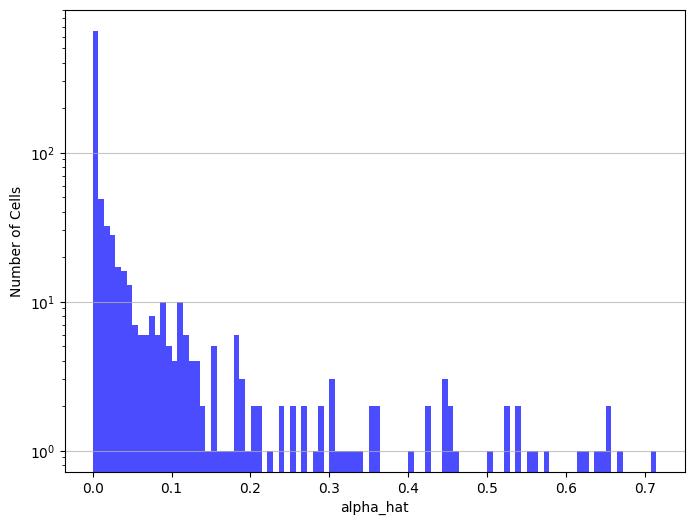

In [11]:
cs_utils.plot_histogram(adata_cellsweep, col="alpha_hat", out_path=os.path.join(out_dir, "alpha_hat_histogram.png"), ylog=True)

## Let's use a threshold to remove noisy cells from our Anndata object

In [12]:
alpha_hat_threshold = 0.3
adata_cellsweep = adata_cellsweep[adata_cellsweep.obs["alpha_hat"] <= alpha_hat_threshold].copy()
adata_cellsweep

AnnData object with n_obs × n_vars = 924 × 36601
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'ambient', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike'
    layers: 'raw'

## Let's make some scatterplots to visualize how much CellSweep modified our counts

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


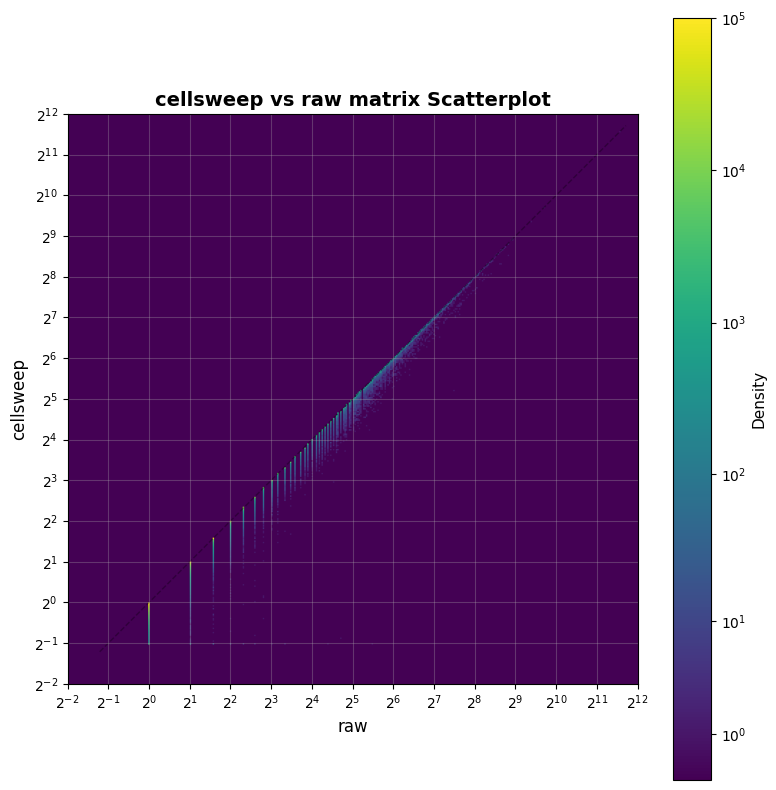

Creating scatterplot...
Calculating scatterplot...


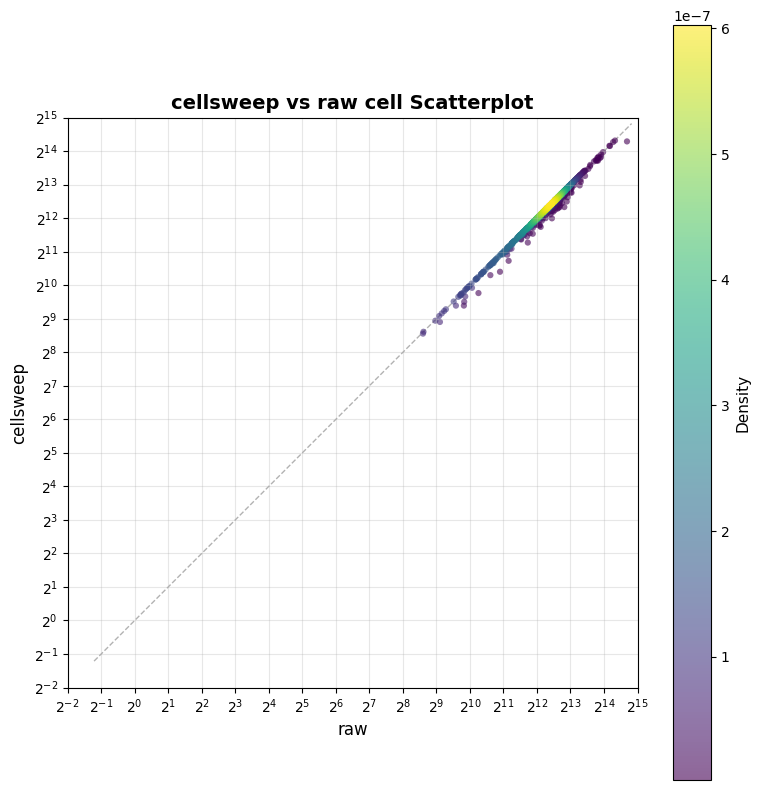

Creating scatterplot...
Calculating scatterplot...


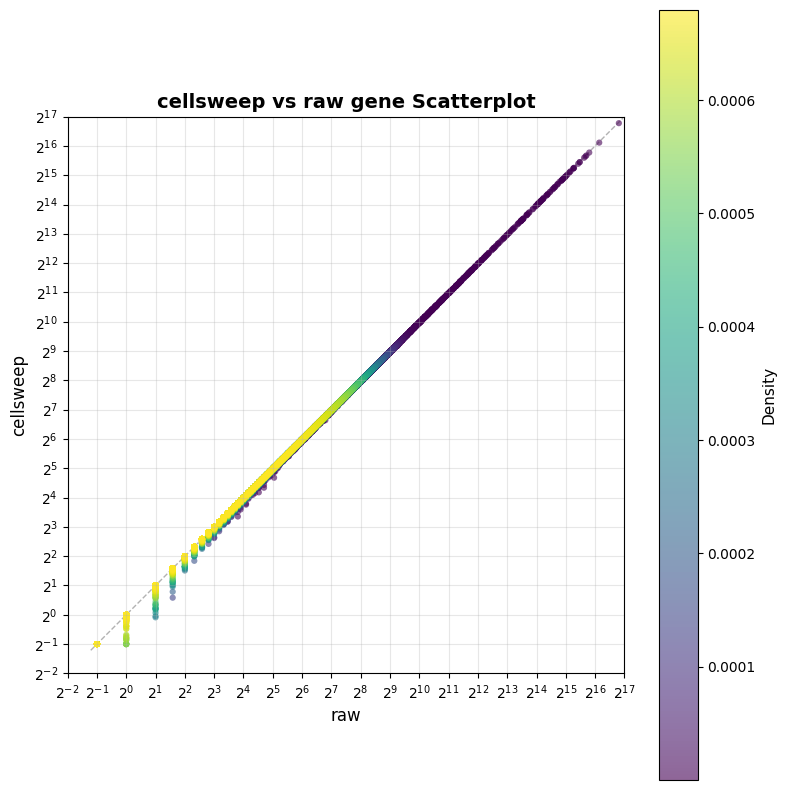

In [13]:
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"cellsweep_vs_raw_matrix_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"cellsweep_vs_raw_cell_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"cellsweep_vs_raw_gene_expression_scatterplot.png"), show=True)

## If you prefer the raw matrix over the CellSweep-corrected matrix, you can access the raw matrix in adata.layers["raw"]

In [14]:
adata_cellsweep.X = adata_cellsweep.layers["raw"]

## That's it! Happy sweeping!